# Clasificación de Mamografías con Redes Neuronales Convolucionales (CNN)

## Marco Teórico y Base de Datos
El objetivo de este proyecto es desarrollar un modelo de Inteligencia Artificial para la clasificación de mamografías, enfocado desde una perspectiva clínica. La categorización se basa en la nomenclatura clínica estándar **BI-RADS** para asegurar su aplicabilidad en escenarios reales.

Para el entrenamiento del modelo, se utiliza la base de datos **TCGA-CBIS-DDSM**. Las categorías de diagnóstico a clasificar son:
1. **Maligno (malignant)**
2. **Benigno** (Se unifican las etiquetas `benign` y `benign_without_callback` dado que su manejo clínico subyacente es equivalente en este contexto).
3. **Normal** (Se ha incorporado un conjunto de datos adicional de imágenes sin hallazgos patológicos provenientes de Vindr, con el objetivo de equilibrar las clases y reducir falsos positivos).

## 1. Descarga del Dataset
En esta sección se inicializa el entorno y se descargan los metadatos e imágenes necesarios para el estudio.

In [ ]:
# Instalación de dependencias
!pip install kagglehub opencv-python pydicom tensorflow pandas matplotlib scikit-learn seaborn ydata-profiling

import os
import gc
import time
import glob
import random
from itertools import cycle

import kagglehub
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from ydata_profiling import ProfileReport

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, classification_report

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Conv2D, Multiply, Concatenate, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Widgets e Interfaz
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

print("Dependencias instaladas e importaciones cargadas correctamente.")

print("Iniciando la descarga de todas las imágenes y archivos del dataset...")
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("=========================================")
print("¡Descarga completada con éxito!")
print("Ruta de los archivos del dataset:", path)
print("=========================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.0 MB/s eta 0:00:00


/tmp/ipykernel_739/2507781790.py:19: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Dependencias instaladas e importaciones cargadas correctamente.
Iniciando la descarga de todas las imágenes y archivos del dataset...
Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
¡Descarga completada con éxito!
Ruta de los archivos del dataset: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset


In [ ]:
# Búsqueda de metadatos en caso de que existan y se hayan descargado (CSV de Calcificaciones y Masas)
rutas_csv = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file in ['calc_case_description_train_set.csv', 'mass_case_description_train_set.csv']:
            rutas_csv.append(os.path.join(root, file))

if len(rutas_csv) > 0:
    dfs = []
    for r in rutas_csv:
        df_temp = pd.read_csv(r)
        # Limpieza de espacios en blanco en las cabeceras
        df_temp.columns = df_temp.columns.str.strip()
        dfs.append(df_temp)

    # Fusión de los conjuntos de datos
    df_completo = pd.concat(dfs, ignore_index=True)
    print(f"CSVs cargados exitosamente. Total de registros clínicos: {len(df_completo)}")
else:
    print("Error: No se encontraron los archivos CSV.")

# 2. Escaneo del directorio y emparejamiento de UIDs
print("\nEscaneando imágenes en el directorio y realizando emparejamiento de UIDs...")
todas_las_imagenes = glob.glob(os.path.join(path, '**', '*.*'), recursive=True)
imagenes_validas = [img for img in todas_las_imagenes if img.lower().endswith(('.jpg', '.jpeg', '.png', '.dcm'))]

mapa_imagenes = {}
for img_path in imagenes_validas:
    carpeta_padre = os.path.basename(os.path.dirname(img_path))
    mapa_imagenes[carpeta_padre] = img_path

def obtener_ruta_real(fila):
    ruta_original = str(fila.get('image file path', ''))
    partes = ruta_original.split('/')
    if len(partes) >= 2:
        uid_serie = partes[-2]
        return mapa_imagenes.get(uid_serie, None)
    return None

df_completo['ruta_completa'] = df_completo.apply(obtener_ruta_real, axis=1)

encontradas = df_completo['ruta_completa'].notna().sum()
print(f"Resultados: Se han enlazado {encontradas} imágenes listas para procesamiento.")

# 3. Balanceo del conjunto de datos
def balancear_dataset_maximo(df, limite_muestras=2000):
    df_valido = df.dropna(subset=['ruta_completa', 'pathology']).copy()
    df_valido['pathology'] = df_valido['pathology'].str.strip().str.upper()

    # 1. Determinar la clase minoritaria
    conteo = df_valido['pathology'].value_counts()
    minimo_disponible = conteo.min()

    # 2. Establecer límite de muestras referenciado a la clase Maligna
    muestras_finales = min(limite_muestras, minimo_disponible)
    print(f"\nBalanceando a {muestras_finales} muestras por clase principal...")
    print("Distribuyendo equitativamente las subclases benignas para evitar sesgos de representación.")

    lista_dfs = []
    for categoria, grupo in df_valido.groupby('pathology'):
        if categoria in ['BENIGN', 'BENIGN_WITHOUT_CALLBACK']:
            # Partición de la muestra benigna
            mitad = muestras_finales // 2
            n_samples = mitad if categoria == 'BENIGN' else (muestras_finales - mitad)
            n_real = min(n_samples, len(grupo))
            muestra = grupo.sample(n=n_real, random_state=42)
        else:
            # Selección completa para la clase Maligna
            n_real = min(muestras_finales, len(grupo))
            muestra = grupo.sample(n=n_real, random_state=42)

        lista_dfs.append(muestra)

    df_balanceado = pd.concat(lista_dfs).reset_index(drop=True)
    return df_balanceado

# Ejecución de la función de balanceo
dataset_listo = balancear_dataset_maximo(df_completo, 3000)

print("\nDistribución final del conjunto de datos tras el balanceo:")
print(dataset_listo['pathology'].value_counts())

CSVs cargados exitosamente. Total de registros clínicos: 2864

Escaneando imágenes en el directorio y realizando emparejamiento de UIDs...
Resultados: Se han enlazado 2864 imágenes listas para procesamiento.

Balanceando a 578 muestras por clase principal...
Distribuyendo equitativamente las subclases benignas para evitar sesgos de representación.

Distribución final del conjunto de datos tras el balanceo:
pathology
MALIGNANT                  578
BENIGN                     289
BENIGN_WITHOUT_CALLBACK    289
Name: count, dtype: int64


In [ ]:
# 1. Descargar el conjunto de datos de control (VinDr)
print("Descargando conjunto de datos adicional...")
path_vindr = kagglehub.dataset_download("shantanughosh/vindr-mammogram-dataset-dicom-to-png")
print("Dataset descargado en la ruta:", path_vindr)

# 2. Cargar anotaciones clínicas
csv_url = "https://raw.githubusercontent.com/batmanlab/Mammo-CLIP/main/src/codebase/data_csv/vindr_detection_v1_folds.csv"
df_vindr = pd.read_csv(csv_url, low_memory=False)

# 3. Filtrar casos catalogados como normales (BI-RADS 1)
if 'breast_birads' in df_vindr.columns:
    normales = df_vindr[df_vindr['breast_birads'].astype(str).str.contains('1')].copy()
else:
    print("Atención: Columnas disponibles:", df_vindr.columns.tolist())
    normales = pd.DataFrame()

# 4. Verificación de archivos físicos en el sistema
print("Verificando la integridad de los archivos de imagen...")
todas_las_imagenes = glob.glob(os.path.join(path_vindr, '**', '*.png'), recursive=True)

# Generar diccionario para mapeo eficiente
mapa_rutas = {os.path.basename(ruta).replace('.png', '').strip(): ruta for ruta in todas_las_imagenes}

def verificar_ruta(row):
    img_id = str(row.get('image_id', '')).replace('.png', '').strip()
    return mapa_rutas.get(img_id, None)

normales['ruta_completa'] = normales.apply(verificar_ruta, axis=1)

# 5. Filtrar rutas válidas
normales_validas = normales[normales['ruta_completa'].notna()].copy()
print(f"\nTotal de mamografías normales validadas: {len(normales_validas)}")

# 6. Muestreo estratificado para equilibrar con el conjunto principal
muestras_referencia = dataset_listo[dataset_listo['pathology'] == 'MALIGNANT'].shape[0]
max_muestras = muestras_referencia if muestras_referencia > 0 else 578

cantidad_a_extraer = min(max_muestras, len(normales_validas))

if cantidad_a_extraer > 0:
    # Extracción submuestral ajustada para optimizar la memoria y mantener el balance
    df_normales_final = normales_validas.sample(n=cantidad_a_extraer, random_state=42)[['ruta_completa']]
    df_normales_final['pathology'] = 'NORMAL'

    # Concatenación final
    dataset_listo = pd.concat([dataset_listo, df_normales_final], ignore_index=True)
    print("\n=========================================")
    print(f"Fusión completada. Se han incorporado {cantidad_a_extraer} muestras de la clase 'Normal'.")
    print("Distribución actualizada del conjunto de datos:")
    print("=========================================")
    print(dataset_listo['pathology'].value_counts())
else:
    print("Error: No se pudo completar la extracción de imágenes de control.")

Descargando conjunto de datos adicional...


100%|██████████| 7.68G/7.68G [06:53<00:00, 19.9MB/s]

Extracting files...


Dataset descargado en la ruta: /root/.cache/kagglehub/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/versions/1
Verificando la integridad de los archivos de imagen...

Total de mamografías normales validadas: 13406

Fusión completada. Se han incorporado 578 muestras de la clase 'Normal'.
Distribución actualizada del conjunto de datos:
pathology
NORMAL                     578
MALIGNANT                  578
BENIGN_WITHOUT_CALLBACK    289
BENIGN                     289
Name: count, dtype: int64


## 2. Proceso de Limpieza y Preprocesamiento
El preprocesamiento es una etapa crítica para el rendimiento del modelo:
* Las imágenes DICOM originales suelen poseer un rango dinámico de 16 bits. Para evitar la pérdida de información y mejorar el contraste local, se aplica el filtro **CLAHE** (Contrast Limited Adaptive Histogram Equalization).
* Se implementa un algoritmo de segmentación para recortar el fondo (aire) y eliminar las etiquetas o marcas del mamógrafo (letras L/R), reduciendo así el ruido que podría afectar al entrenamiento.


In [ ]:
def limpiar_y_preprocesar_dicom(ruta_imagen, target_size=(224, 224)):
    try:
        img = None
        if str(ruta_imagen).lower().endswith('.dcm'):
            ds = pydicom.dcmread(ruta_imagen)
            img = ds.pixel_array
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        else:
            img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

        if img is None or img.size == 0:
            return None

        # Eliminar fondo de aire y etiquetas
        _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c_max = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c_max) < 100:
                return None
            x, y, w, h = cv2.boundingRect(c_max)
            if w == 0 or h == 0:
                return None
            img = img[y:y+h, x:x+w]
        else:
            return None

        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_clahe = clahe.apply(img)

        # Convertir a RGB (nos hace falta por ResNet50V2)
        img_resized = cv2.resize(img_clahe, target_size)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)

        # Normalización de píxeles al rango [-1, 1]
        # (0 -> -1 y 255 -> 1)
        return (img_rgb / 127.5) - 1.0
    except Exception as e:
        return None

### 2.5 Análisis Exploratorio de Datos (EDA)
Antes de alimentar a la red neuronal, es fundamental entender nuestros datos. Aquí comprobamos que el balanceo ha sido exitoso y visualizamos el impacto real de nuestro preprocesamiento (CLAHE + Recorte) para justificar su uso.

/tmp/ipykernel_739/1585587983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_listo, x='pathology', palette='magma')


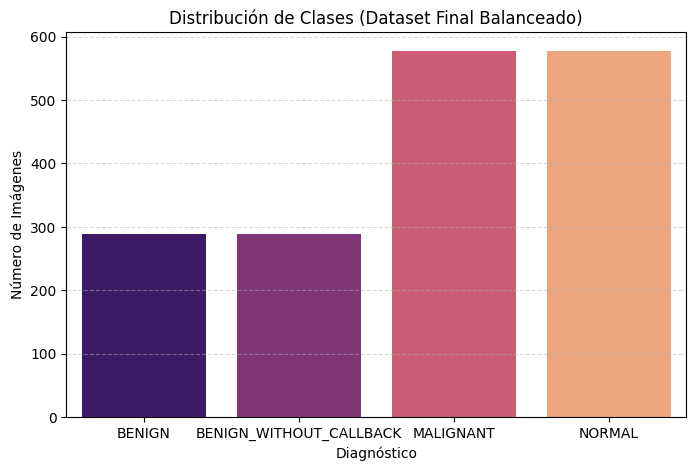


--- Impacto Visual del Preprocesamiento ---


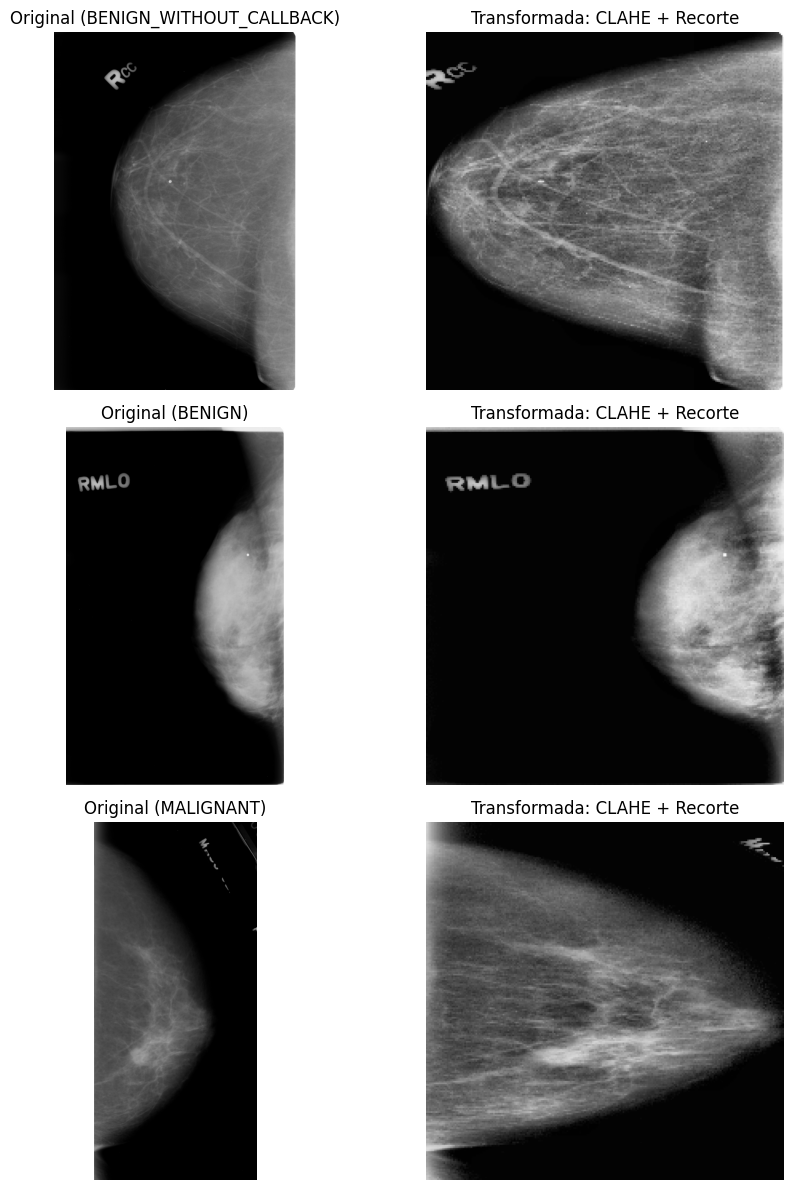

In [ ]:
# 1. Gráfico de Distribución de Clases
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset_listo, x='pathology', palette='magma')
plt.title('Distribución de Clases (Dataset Final Balanceado)')
plt.xlabel('Diagnóstico')
plt.ylabel('Número de Imágenes')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. Visualización Antes y Después del Preprocesamiento
def mostrar_antes_despues(df, num_ejemplos=3):
    fig, axes = plt.subplots(num_ejemplos, 2, figsize=(10, 4*num_ejemplos))
    muestras = df.sample(num_ejemplos, random_state=42) # Fijo para reproducibilidad

    for i, (_, row) in enumerate(muestras.iterrows()):
        ruta = row['ruta_completa']
        cat = row['pathology']

        # Cargar Original
        try:
            if str(ruta).lower().endswith('.dcm'):
                ds = pydicom.dcmread(ruta)
                img_orig = ds.pixel_array
            else:
                img_orig = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

            axes[i, 0].imshow(img_orig, cmap='gray')
            axes[i, 0].set_title(f"Original ({cat})")
            axes[i, 0].axis('off')
        except Exception:
            axes[i, 0].set_title("Error cargando original")
            axes[i, 0].axis('off')

        # Cargar Preprocesada
        img_proc = limpiar_y_preprocesar_dicom(ruta)
        if img_proc is not None:
            # Deshacer normalización [-1, 1] a [0, 255] para visualización
            img_proc_disp = ((img_proc + 1.0) * 127.5).astype(np.uint8)
            axes[i, 1].imshow(img_proc_disp)
            axes[i, 1].set_title(f"Transformada: CLAHE + Recorte")
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

print("\n--- Impacto Visual del Preprocesamiento ---")
mostrar_antes_despues(dataset_listo, 3)

# Se añade una celda que genera el reporte de los datos perfilados

In [ ]:
# Excluir columnas con rutas muy largas que hacen fallar el generador de WordClouds
columnas_a_excluir = ['ruta_completa', 'image file path', 'cropped image file path', 'ROI mask file path']
dataset_perfil = dataset_listo.drop(columns=[col for col in columnas_a_excluir if col in dataset_listo.columns], errors='ignore')

# Crear el reporte de perfilado para el dataset filtrado
profile = ProfileReport(dataset_perfil, title="Reporte de Perfilado del Dataset de Mamografías", explorative=True)

# Mostrar el reporte en el notebook
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 579.61it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 3. Modelo de IA (CNN) y Transfer Learning
En esta fase, se define la arquitectura del modelo utilizando **ResNet50V2** preentrenada, aplicando técnicas de Transfer Learning (Fine-Tuning) para su especialización en imágenes mamográficas.
* **Extracción de características:** Las capas convolucionales intermedias se encargan de identificar patrones morfológicos, texturas del tejido y posibles anomalías como microcalcificaciones.
* **Global Average Pooling:** Se emplea para reducir la dimensionalidad espacial de los mapas de características, minimizando el riesgo de sobreajuste y optimizando la carga computacional.

In [ ]:
def modulo_atencion_espacial(x):
    """
    Módulo de Atención Espacial diseñado para enfocar la red en las regiones
    de interés diagnóstico (ej. microcalcificaciones) y mitigar la influencia del ruido.
    """
    # 1. Agrupación espacial de características
    avg_pool = Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    # 2. Generación del mapa de atención mediante convolución
    mapa_atencion = Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    # 3. Ponderación de las características originales
    return Multiply()([x, mapa_atencion])

def construir_cnn_transfer_learning(num_clases=3):
    # Inicialización del modelo base ResNet50V2 preentrenado en ImageNet
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Configuración de Fine-Tuning
    base_model.trainable = True

    # Congelación de capas inferiores para preservar características genéricas
    for layer in base_model.layers[:-15]:
        layer.trainable = False

    x = base_model.output

    # Integración del módulo de Atención Espacial
    x = modulo_atencion_espacial(x)

    # Reducción de dimensionalidad espacial
    x = GlobalAveragePooling2D()(x)

    # Capa densa con activación no lineal y regularización L2 para prevenir sobreajuste
    x = Dense(512, activation='swish', kernel_regularizer=regularizers.l2(0.01))(x)

    # Normalización por lotes para estabilidad durante el entrenamiento
    x = BatchNormalization()(x)

    # Dropout estratégico
    x = Dropout(0.5)(x)

    # Capa de clasificación final
    predicciones = Dense(num_clases, activation='softmax')(x)

    modelo = Model(inputs=base_model.input, outputs=predicciones)

    optimizador = Adam(learning_rate=1e-4)

    # Implementación de Focal Loss para manejar posibles desbalances intrínsecos de dificultad
    focal_loss = CategoricalFocalCrossentropy(gamma=2.0)

    modelo.compile(optimizer=optimizador, loss=focal_loss, metrics=['accuracy', 'AUC'])
    return modelo

# Instanciación de la arquitectura
modelo_cnn = construir_cnn_transfer_learning(num_clases=3)
print("Arquitectura instanciada: ResNet50V2 + Atención Espacial + Focal Loss.")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Arquitectura instanciada: ResNet50V2 + Atención Espacial + Focal Loss.


## 4. Procesamiento Final y Entrenamiento del Modelo
El objetivo es optimizar el rendimiento del modelo para maximizar el Área Bajo la Curva (AUC), priorizando la sensibilidad en la detección de casos malignos. A continuación, se preparan los lotes de datos, se aplican técnicas de *Data Augmentation* para mejorar la generalización y se configura una función de pérdida focalizada.

In [ ]:
X_data = []
y_labels = []

# Unificación de clases benignas por equivalencia clínica
diccionario_categorias = {
    'malignant': 0,
    'benign': 1,
    'benign_without_callback': 1,
    'normal': 2
}

print("Iniciando flujo de procesamiento de imágenes...")

for index, row in tqdm(dataset_listo.iterrows(), total=len(dataset_listo), desc="Procesando"):
    ruta = row['ruta_completa']
    categoria = str(row['pathology']).lower().strip()

    if categoria in diccionario_categorias:
        img_procesada = limpiar_y_preprocesar_dicom(ruta)

        # Verificación de integridad estructural de la matriz de la imagen
        if np.any(img_procesada):
            X_data.append(img_procesada)
            y_labels.append(diccionario_categorias[categoria])

X_data = np.array(X_data)
y_labels = np.array(y_labels)

if len(X_data) == 0:
    print("Error crítico: Fallo en la lectura del conjunto de datos.")
else:
    print(f"\nProcesamiento finalizado. Muestras válidas retenidas: {len(X_data)}")

    # Conversión a formato One-Hot Encoding
    y_labels_categorical = to_categorical(y_labels, num_classes=3)

    # Partición estratificada de los datos (80% Entrenamiento, 20% Validación Temporal)
    X_train, X_val, y_train, y_val = train_test_split(
        X_data, y_labels_categorical, test_size=0.20, random_state=42, stratify=y_labels_categorical
    )

    print(f"Subconjunto de Entrenamiento: {len(X_train)} muestras")
    print(f"Subconjunto de Validación: {len(X_val)} muestras")

    # Configuración de técnicas de aumento de datos (Data Augmentation)
    print("\nConfigurando pipeline de aumento de datos...")
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )
    datagen.fit(X_train)

    # Early Stopping para evitar overfitting
    callback_parada = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

    # Asignación de pesos asimétricos para penalizar falsos negativos en casos malignos
    pesos_clases = {
        0: 3.0,  # Maligno
        1: 1.0,  # Benigno
        2: 1.0   # Normal
    }

    print("\nIniciando optimización del modelo...")
    historial_entrenamiento = modelo_cnn.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        class_weight=pesos_clases,
        callbacks=[callback_parada],
        verbose=1
    )
    print("Optimización finalizada exitosamente.")

Iniciando flujo de procesamiento de imágenes...


Procesando:   0%|          | 0/1734 [00:00<?, ?it/s]


Procesamiento finalizado. Muestras válidas retenidas: 1734
Subconjunto de Entrenamiento: 1387 muestras
Subconjunto de Validación: 347 muestras

Configurando pipeline de aumento de datos...

Iniciando optimización del modelo...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 54s 767ms/step - AUC: 0.8018 - accuracy: 0.6172 - loss: 8.1884 - val_AUC: 0.8981 - val_accuracy: 0.7089 - val_loss: 7.5161
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step - AUC: 0.8849 - accuracy: 0.6885 - loss: 7.3130 - val_AUC: 0.9094 - val_accuracy: 0.7061 - val_loss: 6.8269
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step - AUC: 0.8982 - accuracy: 0.7094 - loss: 6.6381 - val_AUC: 0.9135 - val_accuracy: 0.7406 - val_loss: 6.2111
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step - AUC: 0.9075 - accuracy: 0.7376 - loss: 6.0272 - val_AUC: 0.9195 - val_accuracy: 0.7493 - val_loss: 5.6567
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - AUC: 0.9155 - accuracy: 0.7224 - loss: 5.4876 - val_AUC: 0.9120 - val_acc

### Visualización del Entrenamiento (Learning Curves)
Para evaluar el comportamiento del modelo durante el entrenamiento, se grafican las curvas de pérdida (Loss) y precisión (Accuracy). Esta visualización es esencial para diagnosticar tempranamente problemas de convergencia o la presencia de sobreajuste (Overfitting) si la métrica de validación comienza a divergir negativamente.

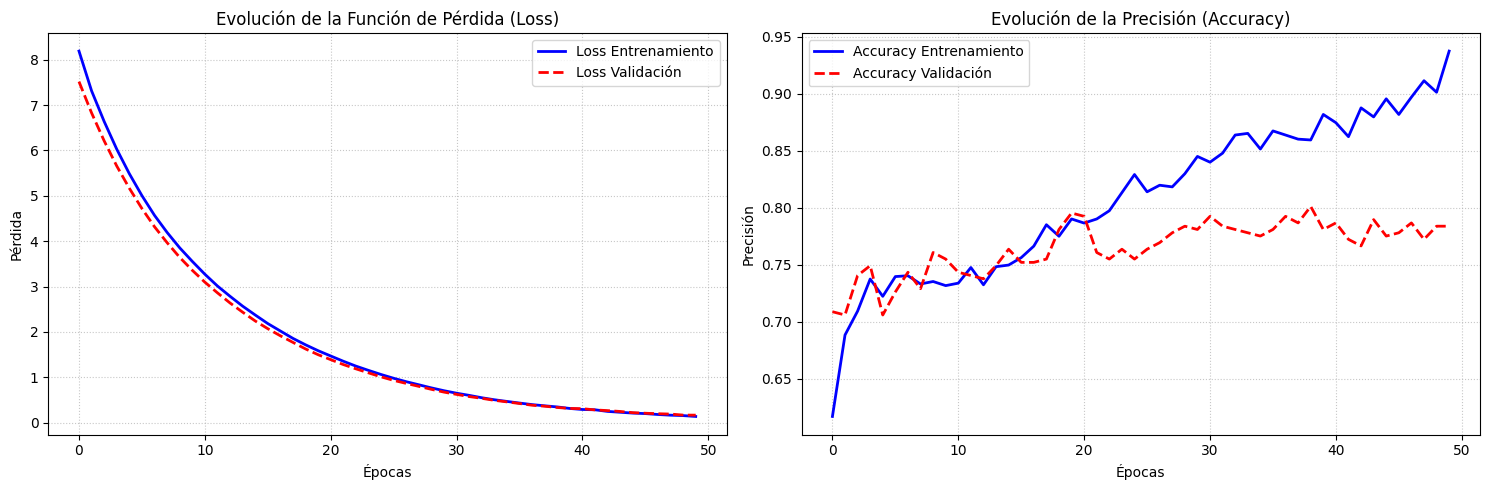

In [ ]:
# Verificamos si existe el historial de entrenamiento
if 'historial_entrenamiento' in locals():
    hist = historial_entrenamiento.history

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfica de Loss (Pérdida)
    axes[0].plot(hist['loss'], label='Loss Entrenamiento', color='blue', linewidth=2)
    axes[0].plot(hist['val_loss'], label='Loss Validación', color='red', linestyle='--', linewidth=2)
    axes[0].set_title('Evolución de la Función de Pérdida (Loss)')
    axes[0].set_xlabel('Épocas')
    axes[0].set_ylabel('Pérdida')
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # Gráfica de Accuracy (Precisión)
    axes[1].plot(hist['accuracy'], label='Accuracy Entrenamiento', color='blue', linewidth=2)
    axes[1].plot(hist['val_accuracy'], label='Accuracy Validación', color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Evolución de la Precisión (Accuracy)')
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Precisión')
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("El modelo aún no ha sido entrenado o la variable 'historial_entrenamiento' no está disponible en memoria.")

### Validación vs Test
Para asegurar una evaluación rigurosa y evitar sesgos metodológicos, el 20% de los datos originalmente reservados se divide en dos subconjuntos independientes:
*   **10% Validación:** Empleado durante el entrenamiento para monitorizar el rendimiento y detener el ajuste tempranamente (Early Stopping).
*   **10% Test:** Conjunto de datos estrictamente aislado (inédito para la red), utilizado únicamente para la evaluación final del modelo.

Se aplica el parámetro de estratificación stratify para garantizar que la distribución de clases se mantenga constante en las tres particiones, preservando la representatividad estadística.

In [ ]:
# 1. Dividir el conjunto de validación original (20%) en Validación (10%) y Test (10%)
X_val_final, X_test_final, y_val_final, y_test_final = train_test_split(
    X_val, y_val, test_size=0.50, random_state=42, stratify=np.argmax(y_val, axis=1)
)

def imprimir_reporte_clinico(X, y_true, nombre_set, porcentaje_set):
    print(f"\nGenerando reporte clínico sobre {nombre_set}...")
    start_time = time.time()
    y_pred_probs = modelo_cnn.predict(X, verbose=0)
    end_time = time.time()

    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_true, axis=1)

    # Calcular métricas de rendimiento
    tiempo_total = end_time - start_time
    muestras = len(X)
    tiempo_promedio_ms = (tiempo_total / muestras) * 1000 if muestras > 0 else 0
    throughput = muestras / tiempo_total if tiempo_total > 0 else 0

    # Calcular métricas clínicas
    acc = accuracy_score(y_true_classes, y_pred_classes) * 100
    correctas = np.sum(y_pred_classes == y_true_classes)
    incorrectas = muestras - correctas
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    clases_nombres = ['Maligno', 'Benigno', 'Normal']

    # Imprimir el reporte estructurado
    print("\n" + "="*70)
    print(f"RESULTADOS: {nombre_set} ({porcentaje_set})")
    print("="*70)
    print(f"Fecha: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*70)

    print("\n⏱️  RENDIMIENTO")
    print("─"*70)
    print(f"Tiempo total de inferencia: {tiempo_total:.4f} segundos")
    print(f"Muestras procesadas: {muestras}")
    print(f"Tiempo promedio por muestra: {tiempo_promedio_ms:.2f} ms")
    print(f"Throughput: {throughput:.2f} muestras/segundo")

    print("\n📊 PRECISIÓN GLOBAL")
    print("─"*70)
    print(f"Accuracy: {acc:.2f}%")
    print(f"Predicciones correctas: {correctas}/{muestras}")
    print(f"Predicciones incorrectas: {incorrectas}/{muestras}")

    print("\n📈 MATRIZ DE CONFUSIÓN")
    print("─"*70)
    print(f"{'':>12} | " + " | ".join([f"{c:>10}" for c in clases_nombres]))
    print("-" * 50)
    for i, row in enumerate(cm):
        print(f"{clases_nombres[i]:>12} | " + " | ".join([f"{val:>10}" for val in row]))

    print("\n🔬 MÉTRICAS CLÍNICAS (Reporte Detallado por Clase)")
    print("─"*70)
    report = classification_report(y_true_classes, y_pred_classes, target_names=clases_nombres)
    print(report)
    print("="*70 + "\n")

# 2. Ejecutar la función para ambos conjuntos (Validación y Test)
imprimir_reporte_clinico(X_val_final, y_val_final, "CONJUNTO DE VALIDACIÓN", "10%")
imprimir_reporte_clinico(X_test_final, y_test_final, "CONJUNTO DE TEST FINAL", "10%")


Generando reporte clínico sobre CONJUNTO DE VALIDACIÓN...

RESULTADOS: CONJUNTO DE VALIDACIÓN (10%)
Fecha: 2026-05-24 11:11:41

⏱️  RENDIMIENTO
──────────────────────────────────────────────────────────────────────
Tiempo total de inferencia: 10.3988 segundos
Muestras procesadas: 173
Tiempo promedio por muestra: 60.11 ms
Throughput: 16.64 muestras/segundo

📊 PRECISIÓN GLOBAL
──────────────────────────────────────────────────────────────────────
Accuracy: 76.88%
Predicciones correctas: 133/173
Predicciones incorrectas: 40/173

📈 MATRIZ DE CONFUSIÓN
──────────────────────────────────────────────────────────────────────
             |    Maligno |    Benigno |     Normal
--------------------------------------------------
     Maligno |         44 |         14 |          0
     Benigno |         26 |         32 |          0
      Normal |          0 |          0 |         57

🔬 MÉTRICAS CLÍNICAS (Reporte Detallado por Clase)
────────────────────────────────────────────────────────────────

### Visualización de Métricas de Rendimiento (Matriz de Confusión y Curvas ROC)
Aquí plasmamos de forma gráfica los resultados obtenidos arriba. La matriz de confusión nos permite ver exactamente dónde se confunde el modelo (Falsos Positivos vs Falsos Negativos), y las Curvas ROC nos muestran la capacidad diagnóstica real para cada clase (especialmente útil para priorizar el Recall en casos Malignos).

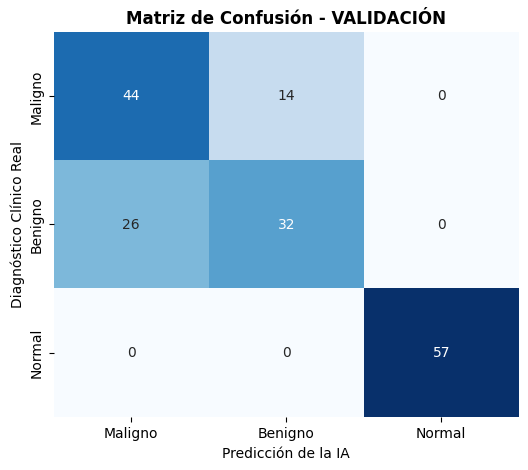

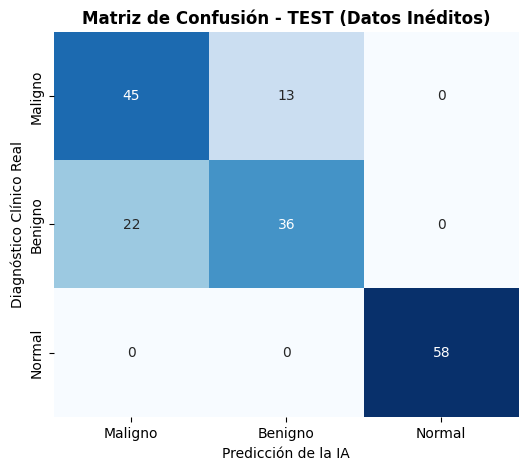

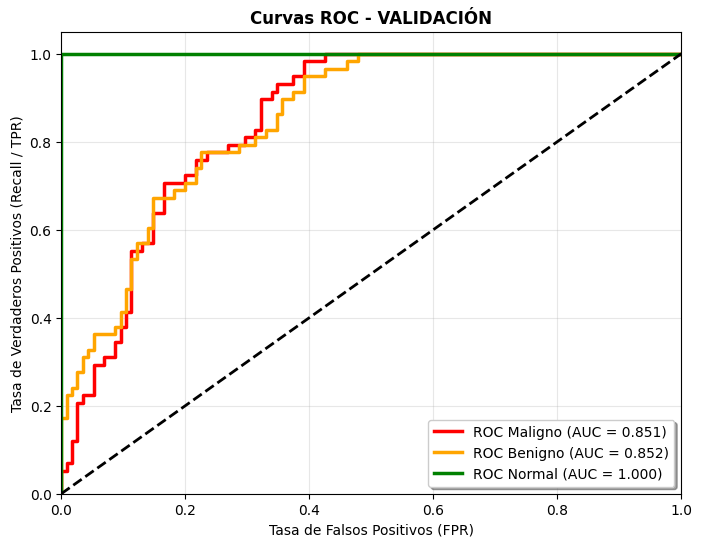

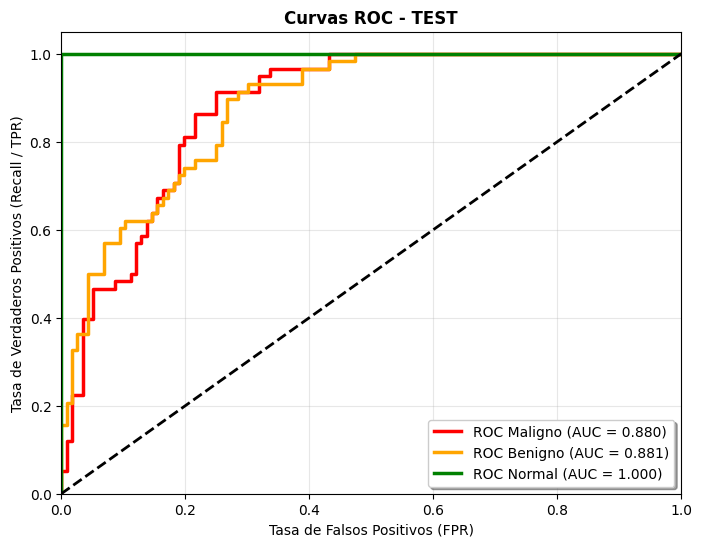

In [ ]:
# Recalcular predicciones puras
y_val_pred_probs = modelo_cnn.predict(X_val_final, verbose=0)
y_val_pred_classes = np.argmax(y_val_pred_probs, axis=1)
y_val_true_classes = np.argmax(y_val_final, axis=1)

y_test_pred_probs = modelo_cnn.predict(X_test_final, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred_probs, axis=1)
y_test_true_classes = np.argmax(y_test_final, axis=1)


# 1. MATRIZ DE CONFUSIÓN

def plot_matriz_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Maligno', 'Benigno', 'Normal'],
                yticklabels=['Maligno', 'Benigno', 'Normal'])
    plt.title(title, fontweight='bold')
    plt.ylabel('Diagnóstico Clínico Real')
    plt.xlabel('Predicción de la IA')
    plt.show()

plot_matriz_confusion(y_val_true_classes, y_val_pred_classes, "Matriz de Confusión - VALIDACIÓN")
plot_matriz_confusion(y_test_true_classes, y_test_pred_classes, "Matriz de Confusión - TEST (Datos Inéditos)")

# 2. CURVAS ROC
def plot_roc(y_true_onehot, y_pred_probs, title):
    n_classes = 3
    fpr = dict(); tpr = dict(); roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = cycle(['red', 'orange', 'green'])
    clases = ['Maligno', 'Benigno', 'Normal']

    for i, color, clase in zip(range(n_classes), colors, clases):
        plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
                 label=f'ROC {clase} (AUC = {roc_auc[i]:0.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
    plt.title(title, fontweight='bold')
    plt.legend(loc="lower right", shadow=True)
    plt.grid(alpha=0.3)
    plt.show()

plot_roc(y_val_final, y_val_pred_probs, "Curvas ROC - VALIDACIÓN")
plot_roc(y_test_final, y_test_pred_probs, "Curvas ROC - TEST")

<!-- Celda unificada arriba -->

## 5. Inferencia sobre Nuevas Imágenes
La siguiente función centraliza el flujo de inferencia. Recibe una ruta de imagen de entrada, le aplica el proceso estandarizado de limpieza (CLAHE y recorte) utilizado durante el entrenamiento, y genera la predicción. Asimismo, incorpora recolección explícita de basura en memoria (`gc.collect()`) para prevenir desbordamientos de RAM durante inferencias secuenciales.

In [ ]:
def clasificar_nueva_mamografia(ruta_nueva_foto, modelo):
    # 1. Aplicamos EXACTAMENTE el mismo preprocesamiento que en el entrenamiento
    # (Recorte, CLAHE, Redimensionado a 224x224, RGB y Normalización / 255)
    img_procesada = limpiar_y_preprocesar_dicom(ruta_nueva_foto)

    if img_procesada is None:
        plt.figure(figsize=(6, 4))
        plt.text(0.5, 0.5, "Error: La imagen no pudo procesarse como una mamografía válida o es de un formato inesperado.",
                 horizontalalignment='center', verticalalignment='center', fontsize=12, color='red')
        plt.axis('off')
        plt.show()
        return "Error de procesamiento: No es una mamografía válida o formato inesperado.", 0.0, -1 # Return 0.0 confidence and -1 index for error

    # 2. Expandir dimensiones para crear un lote (batch) de 1 sola imagen
    img_batch = np.expand_dims(img_procesada, axis=0)

    # 3. Predicción con la IA
    prediccion_probs = modelo.predict(img_batch, verbose=0)
    indice_categoria_original = np.argmax(prediccion_probs[0])
    confianza_original = prediccion_probs[0][indice_categoria_original] * 100

    # Aplicar la lógica de negocio: Si es Benigno con confianza < 60%, forzar a Maligno
    indice_categoria = indice_categoria_original
    confianza = confianza_original

    if indice_categoria_original == 1 and confianza_original < 60.0: # 1 es 'Benigno'
        print(f"DEBUG: Sobreescribiendo la predicción 'Benigno' (Confianza: {confianza_original:.2f}%) a 'Maligno' debido a baja confianza (<60%).")
        indice_categoria = 0 # Forzar a 'Maligno'
        confianza = prediccion_probs[0][0] * 100 # Usar la confianza para 'Maligno'

    # OPTIMIZACIÓN DE RAM: Borrar el batch de memoria lo antes posible
    del img_batch
    gc.collect()

    # Diccionario actualizado para 3 clases
    categorias_inversas = {
        0: 'Maligno (Malignant)',
        1: 'Benigno (Benign)',
        2: 'Normal (Sin hallazgos)'
    }

    resultado_final = categorias_inversas[indice_categoria]

    # Mostrar el resultado garantizando que se vea el formato transformado (224x224)
    plt.figure(figsize=(6, 4))
    plt.imshow(img_procesada)
    plt.title(f"Formato IA (224x224 + CLAHE)\nPredicción: {resultado_final}\nConfianza: {confianza:.2f}%")
    plt.axis('off')
    plt.show()

    # OPTIMIZACIÓN DE RAM: Destruir la imagen procesada al finalizar
    del img_procesada
    gc.collect()

    return resultado_final, confianza, indice_categoria

## 6. Interfaz de Usuario: Panel de Clasificación
Para facilitar la validación funcional del modelo, se provee un widget interactivo implementado con `ipywidgets`. Este módulo simula un entorno clínico básico donde un usuario puede cargar una imagen médica estándar y obtener la evaluación estructurada del modelo.

In [ ]:
# 1. Crear el directorio si no existe
test_dir = 'mamografias_para_test'
os.makedirs(test_dir, exist_ok=True)

print(f"Preparando imágenes de prueba en el directorio '{test_dir}'...")

# Mapeo para traducir las clases del dataset al formato del widget
mapeo_nombres = {
    'NORMAL': 'Normal',
    'MALIGNANT': 'Maligno',
    'BENIGN': 'Benigno',
    'BENIGN_WITHOUT_CALLBACK': 'Benigno'
}

# 2. Coger un par de imágenes de cada clase y convertirlas a PNG
imagenes_guardadas = 0
for clase_original, clase_limpia in mapeo_nombres.items():
    # Cogemos 3 muestras de cada para tener variedad
    muestras = dataset_listo[dataset_listo['pathology'] == clase_original].head(3)

    for idx, row in muestras.iterrows():
        ruta_origen = row['ruta_completa']

        try:
            # Leemos la imagen original (ya sea DICOM o PNG/JPG)
            if str(ruta_origen).lower().endswith('.dcm'):
                ds = pydicom.dcmread(ruta_origen)
                img = ds.pixel_array
            else:
                img = cv2.imread(ruta_origen, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # Normalizamos un poco para que plt.imread lo vea bien luego
                img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                # Guardamos con el sufijo que espera el widget (_REAL_Clase)
                ruta_destino = os.path.join(test_dir, f"ejemplo_{idx}_REAL_{clase_limpia}.png")
                cv2.imwrite(ruta_destino, img_norm)
                imagenes_guardadas += 1
        except Exception as e:
            pass

print(f"¡Listo! Se han guardado {imagenes_guardadas} imágenes de prueba listas para usar.")

Preparando imágenes de prueba en el directorio 'mamografias_para_test'...
¡Listo! Se han guardado 12 imágenes de prueba listas para usar.


In [ ]:
# Global variables
citas_pendientes = []
estado_actual = {'ruta': None, 'real': None, 'indice_ciclo': 0}
clases_ciclo = ['Normal', 'Maligno', 'Benigno']

#  Estilos CSS Modernos
estilo_css = widgets.HTML("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');
    .mi-panel {
        background-color: #ffffff;
        padding: 30px;
        border-radius: 20px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.05);
        border: 1px solid #f0f0f0;
        font-family: 'Inter', sans-serif;
    }
    .mi-titulo {
        color: green;
        font-weight: 700;
        text-align: left;
        font-size: 24px;
        margin-bottom: 5px;
    }
    .mi-subtitulo {
        color: black;
        font-size: 14px;
        margin-bottom: 25px;
        border-bottom: 1px solid #edf2f7;
        padding-bottom: 15px;
    }
    .mi-boton-primario {
        background-color: #3182ce !important;
        color: white !important;
        font-weight: 600 !important;
        border-radius: 12px !important;
        transition: all 0.2s;
    }
    .mi-boton-exito {
        background-color: #38a169 !important;
        color: white !important;
        font-weight: 600 !important;
        border-radius: 12px !important;
    }
    .mi-boton-borrar {
        background-color: #e53e3e !important;
        color: white !important;
        border-radius: 12px !important;
    }
    .card-resultado {
        background-color: #f7fafc;
        border-left: 5px solid #3182ce;
        padding: 20px;
        border-radius: 10px;
        margin-top: 15px;
    }
    .label-input { font-weight: 600; color: white; margin-bottom: 5px; }
</style>
""")

# CSS Elementos
cabecera = widgets.HTML("""
    <div class='mi-titulo'>Radiology AI Suite</div>
    <div class='mi-subtitulo'>Sistema Avanzado de Clasificación de Mamografías v2.0</div>
""")

boton_capturar = widgets.Button(description='📸 Capturar Nueva Placa', layout=widgets.Layout(width='250px', height='50px'))
boton_capturar.add_class('mi-boton-primario')

zona_imagen = widgets.Output(layout=widgets.Layout(display='flex', justify_content='center', margin='20px 0', border='2px dashed #e2e8f0', border_radius='15px'))

patient_name_input = widgets.Text(placeholder='ID del Paciente...', layout=widgets.Layout(width='250px'))

boton_analizar = widgets.Button(description='🔍 Analizar Hallazgos', disabled=True, layout=widgets.Layout(width='200px', height='45px'))
boton_analizar.add_class('mi-boton-exito')

boton_limpiar = widgets.Button(description='🗑️ Limpiar Historial', layout=widgets.Layout(width='180px', height='45px'))
boton_limpiar.add_class('mi-boton-borrar')

zona_resultado = widgets.Output()
zona_tabla = widgets.Output()

def al_pulsar_capturar(b):
    with zona_imagen:
        clear_output()
        test_dir = 'mamografias_para_test'
        imagenes = [f for f in os.listdir(test_dir) if f.endswith('.png')]
        clase_buscada = clases_ciclo[estado_actual['indice_ciclo']]
        imagenes_filtradas = [img for img in imagenes if f"_REAL_{clase_buscada}" in img]

        img_capturada = random.choice(imagenes_filtradas if imagenes_filtradas else imagenes)
        estado_actual['indice_ciclo'] = (estado_actual['indice_ciclo'] + 1) % 3
        estado_actual['ruta'] = os.path.join(test_dir, img_capturada)
        estado_actual['real'] = img_capturada.split('_REAL_')[1].split('.')[0] if '_REAL_' in img_capturada else "Unknown"

        plt.figure(figsize=(5, 4), facecolor='#ffffff')
        plt.imshow(plt.imread(estado_actual['ruta']), cmap='gray')
        plt.title(f"Visualización: {clase_buscada}", color='#2d3748', fontweight='bold')
        plt.axis('off')
        plt.show()
        boton_analizar.disabled = False

def al_pulsar_analizar(b):
    with zona_resultado:
        clear_output()
        nombre = patient_name_input.value.strip()
        if not nombre:
            display(HTML("<p style='color:#e53e3e;'>⚠️ Inserte Identificador</p>"))
            return

        pred_txt, conf, idx = clasificar_nueva_mamografia(estado_actual['ruta'], modelo_cnn)
        color_r = "#38a169" if estado_actual['real'] == "Normal" else ("#e53e3e" if estado_actual['real'] == "Maligno" else "#dd6b20")

        display(HTML(f"""
            <div class='card-resultado'>
                <p style='margin:0; font-size:12px; color:#718096;'>RESULTADO DEL ANÁLISIS</p>
                <h3 style='margin:5px 0; color:#2d3748;'>Paciente: {nombre}</h3>
                <p style='font-size:16px;'>Diagnóstico Clínico Real: <b style='color:{color_r}'>{estado_actual['real']}</b></p>
            </div>
        """))

        citas_pendientes.append({'ID': nombre, 'IA': pred_txt, 'Conf (%)': conf, 'Real': estado_actual['real'], 'sort': idx})
        patient_name_input.value = ''; boton_analizar.disabled = True
        actualizar_tabla()

def actualizar_tabla():
    with zona_tabla:
        clear_output()
        if not citas_pendientes: return
        df = pd.DataFrame(citas_pendientes).sort_values(['sort', 'Conf (%)'], ascending=[True, False])
        display(HTML("<h4 style='margin-top:30px; color:#2d3748;'>Historial de Priorización</h4>"))
        s = df[['ID', 'IA', 'Conf (%)', 'Real']].style.map(lambda x: 'color:#3182ce; font-weight:bold;', subset=['Real'])
        s = s.map(lambda x: 'background-color:#fed7d7; font-weight:bold;' if 'Maligno' in str(x) else '', subset=['IA'])
        display(s.format({"Conf (%)": "{:.1f}%"}).hide(axis='index'))

boton_capturar.on_click(al_pulsar_capturar)
boton_analizar.on_click(al_pulsar_analizar)
boton_limpiar.on_click(lambda b: (citas_pendientes.clear(), zona_tabla.clear_output(), zona_resultado.clear_output()))

controles = widgets.HBox([patient_name_input, boton_analizar, boton_limpiar], layout=widgets.Layout(justify_content='center', gap='15px'))
layout_final = widgets.VBox([estilo_css, cabecera, widgets.HBox([boton_capturar], layout=widgets.Layout(justify_content='center')), zona_imagen, controles, zona_resultado, zona_tabla])
display(layout_final.add_class('mi-panel'))